kernel: 3.11.3

## Imports

In [40]:
import openai
import os

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

from collections import Counter
from datetime import datetime, timedelta
from average_weight_calculator import calculate_weights_by_sector_average

%matplotlib inline


To choose the model, uncomment the row. Comment rows with models that are not used at the moment.

In [41]:
model = "gpt-4"
# model = "gpt-3.5-turbo-0613"
# model = "gpt-4-1106-preview"

To choose whether you want to run prompt for weigths 1 time use avg_weights = False; for 5 times use avg_weigths = True. Uncomment the necessary row, comment the unnecessary ones.

Note: running the prompt for weight assignment in the set of stocks 5 times provides more consistent results. Average weights were used in the research.

In [42]:
avg_weights = True
# avg_weights = False

## Identify sector parameters

To process the sector, uncomment the cell. Comment cells with sectors that are not processed at the moment.

In [43]:
sector_name = 'energy'
sector_name_full = 'Energy'
sector_ticker = '^GSPE'
full_ticker = 'SP500-10'

In [44]:
# sector_name = 'materials'
# sector_name_full = 'Materials'
# sector_ticker = '^SP500-15'
# full_ticker = 'SP500-15'

In [45]:
# sector_name = 'industrials'
# sector_name_full = 'Industrials'
# sector_ticker = '^SP500-20'
# full_ticker = 'SP500-20'

In [46]:
# sector_name = 'consumer_discretionary'
# sector_name_full = 'Consumer Discretionary'
# sector_ticker = '^SP500-25'
# full_ticker = 'SP500-25'

In [47]:
# sector_name = 'consumer_staples'
# sector_name_full = 'Consumer Staples'
# sector_ticker = '^SP500-30'
# full_ticker = 'SP500-30'

In [48]:
# sector_name = 'health_care'
# sector_name_full = 'Health Care'
# sector_ticker = '^SP500-35'
# full_ticker = 'SP500-35'

In [49]:
# sector_name = 'financials'
# sector_name_full = 'Financials'
# sector_ticker = '^SP500-40'
# full_ticker = 'SP500-40'

In [50]:
# sector_name = 'information_technology'
# sector_name_full = 'Information Technology'
# sector_ticker = '^SP500-45'
# full_ticker = 'SP500-45'

In [51]:
# sector_name = 'communication_services'
# sector_name_full = 'Communication Services'
# sector_ticker = '^SP500-50'
# full_ticker = 'SP500-50'

In [52]:
# sector_name = 'utilities'
# sector_name_full = 'Utilities'
# sector_ticker = '^SP500-55'
# full_ticker = 'SP500-55'

In [53]:
# sector_name = 'real_estate'
# sector_name_full = 'Real Estate'
# sector_ticker = '^SP500-60'
# full_ticker = 'SP500-60'

## Process data

In [54]:
sp500_df = pd.read_csv('SP500.csv')
companies = sp500_df[sp500_df['GICS Sector'] == sector_name_full]['Symbol']
companies

38      APA
55      BKR
105     CVX
124     COP
134    CTRA
145     DVN
147    FANG
172     EOG
174     EQT
188     XOM
223     HAL
230     HES
278     KMI
298     MRO
299     MPC
352     OXY
356     OKE
372     PSX
374     PXD
411     SLB
435    TRGP
464     VLO
492     WMB
Name: Symbol, dtype: object

## Load data

In [55]:
## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

## Out-of-sample period (1 Apr 2023 to 1 Dec 2023) (using daily data))
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate   = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [56]:
# in-sample
sp500_ins = yf.download(sector_ticker, start=insample_startdate, end=insample_enddate, interval='1wk')
sp500_ins['SP_Return'] = sp500_ins['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_ins.dropna(subset=['SP_Return'], inplace=True) # 1256 X 7 (removed first row with NaN in return)

# out-of-sample
sp500_outs = yf.download(sector_ticker, start=outsample_startdate, end=outsample_enddate)
sp500_outs['SP_Return'] = sp500_outs['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_outs.dropna(subset=['SP_Return'], inplace=True) # removed first row with NaN in return

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [57]:
insample_data_filename = f'4_returns_insample/SP500_{sector_name}_returns_till_Apr2023.csv'
outsample_data_filename = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'

In [58]:
if os.path.isfile(insample_data_filename):
    print("Reading data from file", insample_data_filename)
    df_returns = pd.read_csv(insample_data_filename, index_col=0)
else:
    print("Retrieving data from Yahoo Finance")
    returns = {}

    for ticker in companies:
        ticker_saved = ticker
        if '.' in ticker: ticker = ticker.replace('.', '-')
        
        try:
            df_temp = yf.download(ticker, start=insample_startdate, end=insample_enddate, interval='1wk')

            df_temp['Return'] = df_temp['Adj Close'].pct_change()

            # removing first row because first return will be Nan
            df_temp = df_temp.iloc[1:]

            df_temp = df_temp[df_temp.index.isin(sp500_ins.index)]

            if df_temp['Return'].isna().any():
                print(f'Skipping {ticker} due to missing returns.')
                continue

            returns[ticker_saved] = df_temp['Return']

        except Exception as e:
            print(f'Failed to download {ticker} due to error: {e}')

    df_returns = pd.DataFrame(returns)
    df_returns.to_csv(insample_data_filename)

Reading data from file 4_returns_insample/SP500_energy_returns_till_Apr2023.csv


In [59]:
df_returns

,APA,BKR,CVX,COP,CTRA,DVN,FANG,EOG,EQT,XOM,...,MRO,MPC,OXY,OKE,PSX,PXD,SLB,TRGP,VLO,WMB
Date,,,,,,,,,,,,,,,,,,,,,
2018-04-09,0.059468,0.101082,0.044964,0.095174,0.021579,0.068362,0.017836,0.089179,0.041578,0.039669,...,0.118227,0.029538,0.090330,0.032104,0.069816,0.120086,0.055780,0.005562,0.069868,0.031583
2018-04-16,0.020433,0.043598,0.019929,0.013714,-0.024926,0.053572,0.081719,0.028301,-0.030501,0.014902,...,-0.007709,0.069312,0.038571,0.017604,0.069886,0.035206,0.018837,0.052876,0.065992,0.014314
2018-04-23,-0.024839,0.059135,0.035239,-0.012768,0.023397,0.009887,-0.019859,0.024744,0.054898,-0.015316,...,0.004994,0.020938,0.007454,0.005711,0.003153,0.022262,-0.002167,-0.004623,0.011331,0.001960
2018-04-30,-0.017172,0.000000,-0.008609,0.029407,-0.008044,0.059301,0.011521,-0.018238,-0.026621,-0.011441,...,0.088901,-0.055140,0.008696,0.073816,0.038351,-0.025591,-0.004198,-0.028288,0.032884,0.024648
2018-05-07,0.048620,-0.006667,0.034334,0.038588,-0.032437,0.081331,-0.027337,0.023984,0.044623,0.056957,...,0.064909,0.005069,0.093424,0.037353,0.018597,0.041094,0.033290,0.065881,0.010936,0.036274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-27,0.049210,0.062541,0.015701,0.032209,0.030516,0.030364,0.030763,0.065727,-0.010942,0.018600,...,0.036733,0.068684,0.038488,0.004293,0.039412,0.067457,0.038390,0.045934,0.063427,-0.006735
2023-03-06,-0.126367,-0.099442,-0.032068,-0.040685,-0.066439,-0.086642,-0.054647,-0.078755,-0.114702,-0.044588,...,-0.096495,-0.037079,-0.022694,-0.050847,-0.045274,-0.026777,-0.089123,-0.071807,-0.063824,-0.066839
2023-03-13,-0.117107,-0.073959,-0.045907,-0.094320,-0.056934,-0.108385,-0.094106,-0.084061,-0.034199,-0.073669,...,-0.115561,-0.038040,-0.020216,-0.076242,-0.064217,-0.084163,-0.123922,-0.082665,-0.043811,-0.005861


In [60]:
if os.path.isfile(outsample_data_filename):
    print("Reading data from file", outsample_data_filename)
    df_returnsOUT = pd.read_csv(outsample_data_filename, index_col=0)
else:
    print("Retrieving data from Yahoo Finance")
    returnsOS = {}

    for ticker in companies:
        ticker_saved = ticker
        if '.' in ticker: ticker = ticker.replace('.', '-')
        
        try:
            df_temp = yf.download(ticker, start=outsample_startdate, end=outsample_enddate)

            df_temp['Return'] = df_temp['Adj Close'].pct_change()
            
            # removing first row because first return will be NaN
            df_temp = df_temp.iloc[1:]            

            df_temp = df_temp[df_temp.index.isin(sp500_outs.index)]

            # If not all dates in S&P 500 data are present in stock data, skip this stock
            if not sp500_outs.index.isin(df_temp.index).all():
                print(f'Skipping {ticker} due to mismatch in trading dates.')
                continue

            # If there are still NaN values in stock returns, skip this stock
            if df_temp['Return'].isna().any():
                print(f'Skipping {ticker} due to missing returns.')
                continue

            returnsOS[ticker_saved] = df_temp['Return']

        except Exception as e:
            print(f'Failed to download {ticker} due to error: {e}')

    df_returnsOUT = pd.DataFrame(returnsOS)
    df_returnsOUT.to_csv(outsample_data_filename)

Reading data from file 4_returns_outsample/SP500_energy_returns_since_Apr2023.csv


In [61]:
df_returnsOUT

,APA,BKR,CVX,COP,CTRA,DVN,FANG,EOG,EQT,XOM,...,MRO,MPC,OXY,OKE,PSX,PXD,SLB,TRGP,VLO,WMB
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-04,-0.028061,-0.022066,-0.005354,-0.019554,-0.001194,-0.010692,-0.019248,-0.014743,0.021384,-0.009558,...,-0.022788,-0.072398,-0.005370,-0.000307,-0.044991,-0.012232,-0.035735,-0.009680,-0.080127,-0.006030
2023-04-05,-0.002887,-0.007179,0.004969,0.013641,0.012754,0.014979,0.009389,0.006270,0.003694,0.017127,...,-0.001166,0.054761,-0.004010,0.014606,0.062576,-0.001708,0.004756,0.008034,0.060111,0.009100
2023-04-06,0.002106,-0.018251,-0.013127,-0.013828,-0.018497,-0.011582,-0.016995,-0.008308,-0.014724,-0.016583,...,-0.007004,-0.030367,-0.023695,-0.004546,-0.015226,-0.010646,-0.021302,-0.004649,-0.018506,-0.009686
2023-04-10,0.026793,0.011224,0.003817,-0.002917,0.028468,0.009072,0.018783,0.008377,0.039539,-0.004433,...,0.009404,0.019894,0.016656,0.005785,0.020615,0.057936,0.008464,0.006273,0.018931,0.006408
2023-04-11,0.021233,0.011099,0.005526,0.007551,0.012086,0.017044,0.013828,0.010883,0.000898,0.007072,...,0.013587,0.007239,0.004369,0.005449,0.014291,0.000772,0.021982,0.012201,0.011917,0.011059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-24,0.008753,0.009232,0.003949,0.005572,0.003750,0.004207,0.003049,0.002679,0.013145,0.005384,...,0.004358,0.001944,-0.000830,0.009901,0.005254,0.006095,0.001523,0.007108,-0.003191,0.002484
2023-11-27,-0.014642,0.002361,-0.003727,-0.005974,-0.018678,-0.009261,-0.003945,-0.004049,-0.015177,-0.005833,...,-0.001183,0.007023,-0.004821,-0.001634,-0.002529,-0.005427,-0.000951,0.001480,0.005202,0.001927
2023-11-28,0.001101,-0.004416,0.007966,0.001568,-0.007613,-0.002448,-0.000195,0.005203,-0.009446,-0.000577,...,0.000000,-0.003720,0.003174,-0.003273,-0.002789,-0.001227,-0.004567,-0.005343,-0.002946,-0.001649


In [62]:
index_tickers = ["^GSPC", "^DJI", "^IXIC", sector_ticker]

index_data_outs = pd.DataFrame()

# Download historical data for each index for out-of-sample period
for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

index_data_outs.index = pd.to_datetime(index_data_outs.index)

valid_index_tickers_outs = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPC', '^DJI', '^IXIC', '^GSPE']


## ChatGPT API

In [63]:
with open('api_key.txt', 'r', encoding='utf-8') as f:
    API_KEY = f.readline()

os.environ['OPENAI_API_KEY'] =API_KEY
openai.api_key = os.getenv("OPENAI_API_KEY")

In [64]:
# OpenAI API parameters
max_tokens = 1024
n = 1
stop = None
temperature = 0.5

In [65]:
def generate_stocks_by_sector(sector_name, full_ticker, n_count, n_stocks, valid_tickers, recount=False):
    if model == 'gpt-4':
        csv_path = f'cached/4_sectors/stocks15_auto_{sector_name}.csv'
    elif model == "gpt-4-1106-preview":
        csv_path = f'cached/4preview_sectors/stocks15_auto_{sector_name}.csv'
    else:
        csv_path = f'cached/3_sectors/stocks15_auto_{sector_name}.csv'

    if os.path.isfile(csv_path) and not recount:
        df = pd.read_csv(csv_path)
        print("Reading from local csv file")

        stock_counter = df.set_index('Stocks')['Count'].to_dict()
        valid_most_common_stocks = df.loc[df['IsValid'] == 1, 'Stocks'].tolist()
        
        print(stock_counter)
        print("The valid most common stocks are: ", valid_most_common_stocks)


    else:    
        prompt1 = f"Using a range of investing principles taken from leading funds, create a theoretical fund comprising of at least {n_stocks} stocks (mention their tickers) from the {full_ticker} {sector_name} sector with the goal to outperform the {full_ticker} {sector_name} sector"

        stock_counter = Counter()

        num_stocks_per_iter = []

        for i in range(n_count):
            response1 = openai.ChatCompletion.create(
                model=model,
                messages=[
                {"role": "system", "content": "You are a helpful  assistant."},
                {"role": "user", "content": prompt1},
                ],
                max_tokens=max_tokens,
                n=n,
                stop=stop,
                temperature=temperature,
            )

            coutput1 = response1['choices'][0]['message']['content']

            prompt2 = 'Extract only the ticker symbols of the stocks comprising the fund from the previous response:- "{input}". In your response to this prompt, list only the ticker symbols separated by spaces.'.format(input=coutput1)

            response2 = openai.ChatCompletion.create(
                model=model,
                messages=[
                {"role": "system", "content": "You are a helpful  assistant."},
                {"role": "user", "content": prompt2},
                ],
                max_tokens=max_tokens,
                n=n,
                stop=stop,
                temperature=temperature,
            )

            coutput2 = response2['choices'][0]['message']['content']

            stock_tickers = coutput2.split()

            # stock_tickers = [ticker.replace(".", "-") for ticker in stock_tickers]

            stock_tickers = ["META" if ticker == "FB" else ticker for ticker in stock_tickers]
            print(stock_tickers)

            num_stocks_per_iter.append(len(stock_tickers))
            print(num_stocks_per_iter)

            stock_counter.update(stock_tickers)
            print(stock_counter)

        average = round(np.mean(num_stocks_per_iter))

        # Get a list of all the stocks, sorted by frequency (from most to least common)
        sorted_stocks = [stock for stock, _ in stock_counter.most_common()]

        valid_tickers = set(valid_tickers)

        valid_most_common_stocks = []

        for stock in sorted_stocks:
            # If the stock is valid and we still need more stocks to reach the number 15
            if stock in valid_tickers and len(valid_most_common_stocks) < 15:
                valid_most_common_stocks.append(stock)
            elif stock not in valid_tickers:
                print(f"The stock {stock} is not in the valid list of this S&P 500 sector and hence is being discarded.")

        if len(valid_most_common_stocks) < 15:
            print("There are not enough valid stocks to reach the desired number of 15 stocks.")

        print("The valid most common stocks are: ", valid_most_common_stocks)
        
        df = pd.DataFrame.from_dict(stock_counter, orient='index', columns=['Count']).reset_index().rename(columns={'index': 'Stocks'})
        df['IsValid'] = df['Stocks'].apply(lambda x: 1 if x in valid_most_common_stocks else 0)

        df.to_csv(csv_path, index=False)


In [66]:
generate_stocks_by_sector(sector_name, full_ticker, 10, 15, companies)
print(f'Processed  sector {sector_name}')


Reading from local csv file
{'XOM': 10, 'CVX': 10, 'COP': 10, 'EOG': 10, 'KMI': 10, 'PSX': 10, 'VLO': 10, 'PXD': 10, 'MPC': 10, 'HES': 6, 'OXY': 10, 'HAL': 8, 'SLB': 8, 'BKR': 8, 'DVN': 8, 'WMB': 5, 'OKE': 4, 'FANG': 2, 'APA': 1}
The valid most common stocks are:  ['XOM', 'CVX', 'COP', 'EOG', 'KMI', 'PSX', 'VLO', 'PXD', 'MPC', 'HES', 'OXY', 'HAL', 'SLB', 'BKR', 'DVN']
Processed  sector energy


## Count stocks outside of sector

In [67]:
if model == 'gpt-4':
    csv_path = f'cached/4_sectors/stocks15_auto_{sector_name}.csv'
elif model == "gpt-4-1106-preview":
    csv_path = f'cached/4preview_sectors/stocks15_auto_{sector_name}.csv'
else:
    csv_path = f'cached/3_sectors/stocks15_auto_{sector_name}.csv'

df_count = pd.read_csv(csv_path)

counter_invalid = 0
for stock in df_count['Stocks']:
    if not (stock in list(companies)):
        counter_invalid += 1
        print(stock)

print(counter_invalid)

0


## Count stocks

In [68]:
SMALL2_SIZE = 6
SMALL1_SIZE = 7
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('xtick', labelsize=SMALL_SIZE)

In [69]:
def plot_selected_by_sector(sector):
    if model == 'gpt-4':
        csv_path = f'cached/4_sectors/stocks15_auto_{sector_name}.csv'
    elif model == "gpt-4-1106-preview":
        csv_path = f'cached/4preview_sectors/stocks15_auto_{sector_name}.csv'
    else:
        csv_path = f'cached/3_sectors/stocks15_auto_{sector_name}.csv'

    temp_df = pd.read_csv(csv_path)
    temp_df = temp_df.sort_values(by='IsValid', ascending=False)

    stock_counter = temp_df.set_index('Stocks')['Count'].to_dict()
    print('Number of stocks in the universe before selecting 15: ', len(stock_counter))
    valid_most_common_stocks = temp_df.loc[temp_df['IsValid'] == 1, 'Stocks'].tolist()

    plt.figure(figsize=(10, 6))

    tickers, counts = zip(*stock_counter.items())

    colors = ['red' if ticker in valid_most_common_stocks else 'blue' for ticker in tickers]

    k_value_case1 = len(valid_most_common_stocks)

    plt.bar(tickers, counts, color=colors)
    plt.xlabel('Stock tickers')
    plt.ylabel('Number of occurrences')
    plt.xticks(rotation=90)
    plt.tight_layout()
    # plt.savefig('GPT_'+str(k_value_case1)+'_instr_universe.eps', format='eps', dpi=1200)
    # plt.savefig('GPT_'+str(k_value_case1)+'_instr_universe.png', format='png', dpi=600)
    plt.title(f'Selected stocks in {sector_name_full} sector')
    plt.show()

    print(f'Processed {sector} sector')

BLUE means also stock can be not valid

Number of stocks in the universe before selecting 15:  19


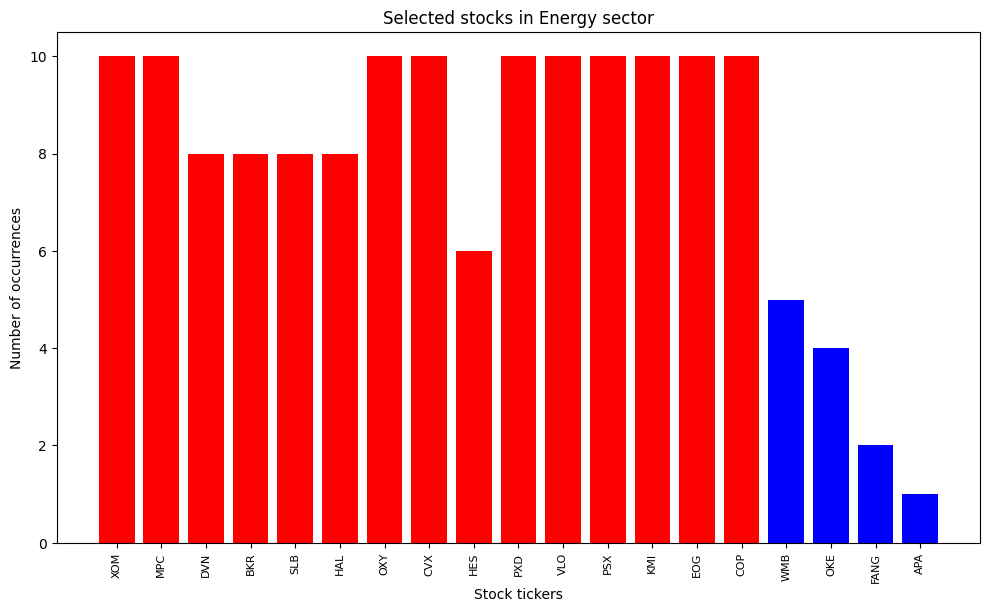

Processed energy sector


In [70]:
plot_selected_by_sector(sector_name)

## Weighted GPT portfolio

In [71]:
def convert_reponse4_to_df(coutput4):
    df = pd.DataFrame()
    pairs = coutput4.split(',')
    stocks, weights = [], []

    for pair in pairs:
        stock, weight = pair.split(':')
        stocks.append(stock)
        weights.append(float(weight))

    df = pd.DataFrame({'Stock': stocks, 'Weight': weights})

    if not np.isclose(df['Weight'].sum(), 1):
        df['Weight'] = df['Weight'] / df['Weight'].sum()

    return df

In [72]:
def get_weights_by_sector(sector_name, full_ticker):
    if model == 'gpt-4':
        csv_path_read = f'cached/4_sectors/stocks15_auto_{sector_name}.csv'
    elif model == "gpt-4-1106-preview":
        csv_path_read = f'cached/4preview_sectors/stocks15_auto_{sector_name}.csv'
    else:
        csv_path_read = f'cached/3_sectors/stocks15_auto_{sector_name}.csv'

    sector_df = pd.read_csv(csv_path_read)

    temp_df = sector_df[sector_df['IsValid'] == 1]
    input = temp_df['Stocks'].to_list()
    print(input)
    prompt3 = f"Assume you're designing a theoretical model portfolio from these {full_ticker} {sector_name} stocks: {input}. Provide a hypothetical example of how you might distribute the weightage of these stocks (normalized i.e weights should add up to 1.00) in the portfolio to potentially outperform the {full_ticker} {sector_name} index. Also mention the underlying strategy or logic which you used to assign these weights"
    prompt3

    if model == 'gpt-4':
        csv_path = f'cached/4_weights_response/responses15_auto_{sector_name}.csv'
    elif model == "gpt-4-1106-preview":
        csv_path = f'cached/4preview_weights_response/responses15_auto_{sector_name}.csv'
    else:
        csv_path = f'cached/3_weights_response/responses15_auto_{sector_name}.csv'

    if os.path.isfile(csv_path):
        print("Reading from local csv file")
        with open(csv_path, 'r', encoding='utf-8') as f:
            coutput3 = f.read()

    else:
        response3 = openai.ChatCompletion.create(
            model=model,
            messages=[
            {"role": "system", "content": "You are a helpful assistant. Your task is to create a hypothetical allocation of weights to the stocks in a theoretical investment fund."},
            {"role": "user", "content": prompt3},
            ],
            max_tokens=max_tokens,
            n=n,
            stop=stop,
            temperature=temperature,
        )

        coutput3 = response3['choices'][0]['message']['content']
        with open(csv_path, 'w', encoding='utf-8') as f:
            f.write(coutput3)


    prompt4 = f'Extract tickers of stocks and corresponding weights as a single comma "," separated string, with the weights expressed as floats : "{coutput3}". Provide a list of type TICKER: weight, no extra symbols used.'


    if model == 'gpt-4':
        csv_path = f'cached/4_weights_assigned/responses15_auto_{sector_name}.csv'
    elif model == "gpt-4-1106-preview":
        csv_path = f'cached/4preview_weights_assigned/responses15_auto_{sector_name}.csv'
    else:
        csv_path = f'cached/3_weights_assigned/responses15_auto_{sector_name}.csv'

    if os.path.isfile(csv_path):
        print("Reading from local csv file")
        coutput4 = pd.read_csv(csv_path)

    else:
        print(f'calling openai for response to prompt 4 sector {sector_name}')
        response4 = openai.ChatCompletion.create(
            model=model,
            messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt4},
            ],
            max_tokens=max_tokens,
            n=n,
            stop=stop,
            temperature=temperature,
        )

        coutput4 = response4['choices'][0]['message']['content']
        print(coutput4.strip('"'))

        weights_df = convert_reponse4_to_df(coutput4)

        weights_df.to_csv(csv_path, index=False)

    return coutput4


In [73]:
if not avg_weights:
    get_weights_by_sector(sector_name, full_ticker)
else:
    params = (max_tokens, n, stop, temperature)
    calculate_weights_by_sector_average(sector_name, full_ticker, model, params)

Reading from local csv file
   Stock    Weight
0    XOM  0.149701
1    CVX  0.133733
2    COP  0.105788
3    EOG  0.095808
4    KMI  0.083832
5    PSX  0.079840
6    VLO  0.073852
7    PXD  0.063872
8    MPC  0.055888
9    HES  0.047904
10   OXY  0.037924
11   HAL  0.029940
12   SLB  0.019960
13   BKR  0.013972
14   DVN  0.007984


In [74]:
def normalise_from_csv(path):
    df_temp = pd.read_csv(path)

    for i in range(5):
        if not np.isclose(df_temp[f'Weight_{i}'].sum(), 1):
            df_temp[f'Weight_{i}'] = df_temp[f'Weight_{i}'] / df_temp[f'Weight_{i}'].sum()
    df_temp.to_csv(path)

    return df_temp

In [75]:
if model == 'gpt-4':
    csv_path_write_avg = f'cached/4_avg_weights_response/responses15_auto_{sector_name}.csv'
elif model == "gpt-4-1106-preview":
    csv_path_write_avg = f'cached/4preview_avg_weights_response/responses15_auto_{sector_name}.csv'
else:
    csv_path_write_avg = f'cached/3_avg_weights_response/responses15_auto_{sector_name}.csv'

normalise_from_csv(csv_path_write_avg)

,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Stock,Weight_0,Weight_1,Weight_2,Weight_3,Weight_4
0,0,0,0,0,0,0,XOM,0.15,0.15,0.178218,0.15,0.12
1,1,1,1,1,1,1,CVX,0.12,0.13,0.158416,0.15,0.11
2,2,2,2,2,2,2,COP,0.10,0.12,0.108911,0.10,0.10
3,3,3,3,3,3,3,EOG,0.10,0.10,0.089109,0.10,0.09
4,4,4,4,4,4,4,KMI,0.08,0.09,0.089109,0.08,0.08
5,5,5,5,5,5,5,PSX,0.08,0.08,0.079208,0.08,0.08
6,6,6,6,6,6,6,VLO,0.08,0.07,0.069307,0.07,0.08
7,7,7,7,7,7,7,PXD,0.07,0.06,0.059406,0.06,0.07
8,8,8,8,8,8,8,MPC,0.05,0.05,0.049505,0.06,0.07
9,9,9,9,9,9,9,HES,0.05,0.04,0.039604,0.05,0.06


## Weight volatility

In [76]:
if model == 'gpt-4':
    csv_path_write_avg = f'cached/4_avg_weights_response/responses15_auto_{sector_name}.csv'
elif model == "gpt-4-1106-preview":
    csv_path_write_avg = f'cached/4preview_avg_weights_response/responses15_auto_{sector_name}.csv'
else:
    csv_path_write_avg = f'cached/3_avg_weights_response/responses15_auto_{sector_name}.csv'

dfw = pd.read_csv(csv_path_write_avg)

fig = px.box(dfw, x='Stock', y=['Weight_0', 'Weight_1', 'Weight_2', 'Weight_3', 'Weight_4'], points="all",
             title=f"Weight volatility for {full_ticker} {sector_name} sector ({model} model)",
             labels={'variable': 'Columns', 'value': 'Weight'})

fig.update_layout(height=600, width=900)
fig.show()


In [77]:
if model == 'gpt-4' and not avg_weights:
    df_15 = pd.read_csv(f'cached/4_weights_assigned/responses15_auto_{sector_name}.csv')
elif model == 'gpt-3.5-turbo-0613' and not avg_weights:
    df_15 = pd.read_csv(f'cached/3_weights_assigned/responses15_auto_{sector_name}.csv')
elif model == 'gpt-4-1106-preview' and not avg_weights:
    df_15 = pd.read_csv(f'cached/4preview_weights_assigned/responses15_auto_{sector_name}.csv')

elif model == 'gpt-4' and avg_weights:
    df_15 = pd.read_csv(f'cached/4_avg_weights_assigned/responses15_auto_{sector_name}.csv')
elif model == 'gpt-3.5-turbo-0613' and avg_weights:
    df_15 = pd.read_csv(f'cached/3_avg_weights_assigned/responses15_auto_{sector_name}.csv')
elif model == 'gpt-4-1106-preview' and avg_weights:
    df_15 = pd.read_csv(f'cached/4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv')

df_15

,Stock,Weight
0,XOM,0.149701
1,CVX,0.133733
2,COP,0.105788
3,EOG,0.095808
4,KMI,0.083832
5,PSX,0.079840
6,VLO,0.073852
7,PXD,0.063872
8,MPC,0.055888
9,HES,0.047904


In [78]:
sum(df_15['Weight'])

0.9999999999999994